# Klasifikasi Prioritas Keluhan Mahasiswa Terhadap Fasilitas dan Layanan Akademik Universitas Halu Oleo Menggunakan Perbandingan Algoritma Machine Learning

## Deskripsi Penelitian

Penelitian ini bertujuan untuk membangun model Machine Learning yang mampu mengklasifikasikan tingkat prioritas keluhan mahasiswa terhadap fasilitas dan layanan akademik Universitas Halu Oleo.

Dataset yang digunakan terdiri dari data keluhan mahasiswa yang telah memiliki label prioritas:

- Rendah
- Sedang
- Tinggi

Tahapan penelitian meliputi:

1. Import Library
2. Load Dataset
3. Data Understanding
4. Data Cleaning
5. Exploratory Data Analysis (EDA)
6. Analisis Prioritas Keluhan
7. Analisis Teks Keluhan
8. Text Preprocessing
9. Feature Extraction TF-IDF
10. Data Splitting
11. Perbandingan Model Machine Learning
12. Evaluasi Model
13. Pemilihan Model Terbaik
14. Cross Validation
15. Analisis Overfitting
16. Learning Curve
17. Feature Importance
18. Prediksi Data Baru
19. Kesimpulan

# 1. Import Library

Mengimpor seluruh library yang digunakan dalam penelitian.

In [56]:
# ==================================================
# IMPORT LIBRARY
# ==================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import re

from collections import Counter

from wordcloud import WordCloud

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    learning_curve
)

from sklearn.feature_extraction.text import (
    TfidfVectorizer
)

from sklearn.pipeline import Pipeline

# Model

from sklearn.linear_model import LogisticRegression

from sklearn.svm import LinearSVC

from sklearn.naive_bayes import MultinomialNB

from sklearn.ensemble import RandomForestClassifier

# Evaluasi

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

plt.rcParams["figure.figsize"] = (10,6)

print("Library berhasil dimuat")

Library berhasil dimuat


# 2. Memuat Dataset

Dataset berisi data keluhan mahasiswa mengenai fasilitas dan layanan akademik Universitas Halu Oleo.

In [57]:
# =====================================================
# MEMBACA DATASET
# =====================================================

df = pd.read_excel(
    "data_klmpk10_sintetis.xlsx"
)

# Menampilkan 5 data pertama
df.head()

,Timestamp,Email Address,Nama Lengkap,Program Studi,Angkatan,Kategori Keluhan,Keluhan,Prioritas,Tingkat Gangguan,Tingkat Urgensi,Lokasi Keluhan,Column 10
0,2026-06-23 08:00:00,nandakusuma1@example.com,Nanda Kusuma,Teknik Geologi,2023,Fasilitas,Kondisi toilet di Gazebo kadang tidak mendukun...,Rendah,2,2,Laboratorium,NaN
1,2026-06-23 08:03:00,nandaaulia2@example.com,Nanda Aulia,Kimia,2022,Fasilitas,Kondisi speaker di Gedung C kadang tidak mendu...,Rendah,1,2,Kantin,NaN
2,2026-06-23 08:06:00,rakaramadhani3@example.com,Raka Ramadhani,Ilmu Komputer,2023,Fasilitas,kursi di Laboratorium kadang kurang optimal se...,Rendah,1,2,Gazebo,NaN
3,2026-06-23 08:09:00,salsafadilah4@example.com,Salsa Fadilah,Ilmu Komputer,2025,Fasilitas,kursi di Gazebo agak kurang optimal sehingga k...,Rendah,1,1,Gedung A,NaN
4,2026-06-23 08:12:00,aditaulia5@example.com,Adit Aulia,Teknik Geologi,2022,Fasilitas,meja di Gedung B kadang kurang optimal sehingg...,Rendah,1,2,Gedung C,NaN


# 3. Dataset Overview

Tahap ini bertujuan untuk memahami ukuran dataset serta struktur data yang digunakan.

In [13]:
# Jumlah data dan kolom

print("Jumlah Baris :", df.shape[0])
print("Jumlah Kolom :", df.shape[1])

Jumlah Baris : 140
Jumlah Kolom : 12


In [14]:
# Informasi dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Timestamp         140 non-null    datetime64[ns]
 1   Email Address     140 non-null    object        
 2   Nama Lengkap      140 non-null    object        
 3   Program Studi     140 non-null    object        
 4   Angkatan          140 non-null    int64         
 5   Kategori Keluhan  140 non-null    object        
 6   Keluhan           140 non-null    object        
 7   Prioritas         140 non-null    object        
 8   Tingkat Gangguan  140 non-null    int64         
 9   Tingkat Urgensi   140 non-null    int64         
 10  Lokasi Keluhan    140 non-null    object        
 11  Column 10         0 non-null      float64       
dtypes: datetime64[ns](1), float64(1), int64(3), object(7)
memory usage: 13.3+ KB


In [15]:
# Statistik deskriptif

df.describe(include='all')

,Timestamp,Email Address,Nama Lengkap,Program Studi,Angkatan,Kategori Keluhan,Keluhan,Prioritas,Tingkat Gangguan,Tingkat Urgensi,Lokasi Keluhan,Column 10
count,140,140,140,140,140.000000,140,140,140,140.000000,140.000000,140,0.0
unique,NaN,140,127,7,NaN,7,139,3,NaN,NaN,8,NaN
top,NaN,nandakusuma1@example.com,Reza Maulana,Teknik Pertambangan,NaN,Fasilitas,Proses pembayaran UKT di Gedung A masih sering...,Tinggi,NaN,NaN,Gedung A,NaN
freq,NaN,1,3,28,NaN,20,2,64,NaN,NaN,25,NaN
mean,2026-06-23 11:28:30,NaN,NaN,NaN,2023.457143,NaN,NaN,NaN,3.450000,3.600000,NaN,NaN
min,2026-06-23 08:00:00,NaN,NaN,NaN,2022.000000,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN
25%,2026-06-23 09:44:15,NaN,NaN,NaN,2022.000000,NaN,NaN,NaN,3.000000,3.000000,NaN,NaN
50%,2026-06-23 11:28:30,NaN,NaN,NaN,2024.000000,NaN,NaN,NaN,4.000000,4.000000,NaN,NaN
75%,2026-06-23 13:12:45,NaN,NaN,NaN,2024.000000,NaN,NaN,NaN,4.000000,4.000000,NaN,NaN
max,2026-06-23 14:57:00,NaN,NaN,NaN,2025.000000,NaN,NaN,NaN,5.000000,5.000000,NaN,NaN


# 4. Missing Value Analysis

Mengecek apakah terdapat data kosong yang dapat memengaruhi proses analisis.

In [16]:
# Mengecek missing value

df.isnull().sum()

,0
Timestamp,0
Email Address,0
Nama Lengkap,0
Program Studi,0
Angkatan,0
Kategori Keluhan,0
Keluhan,0
Prioritas,0
Tingkat Gangguan,0
Tingkat Urgensi,0


# 5. Exploratory Data Analysis (EDA)

Tahap ini digunakan untuk memahami karakteristik dataset sebelum dilakukan proses Machine Learning.

### Distribusi Program Studi

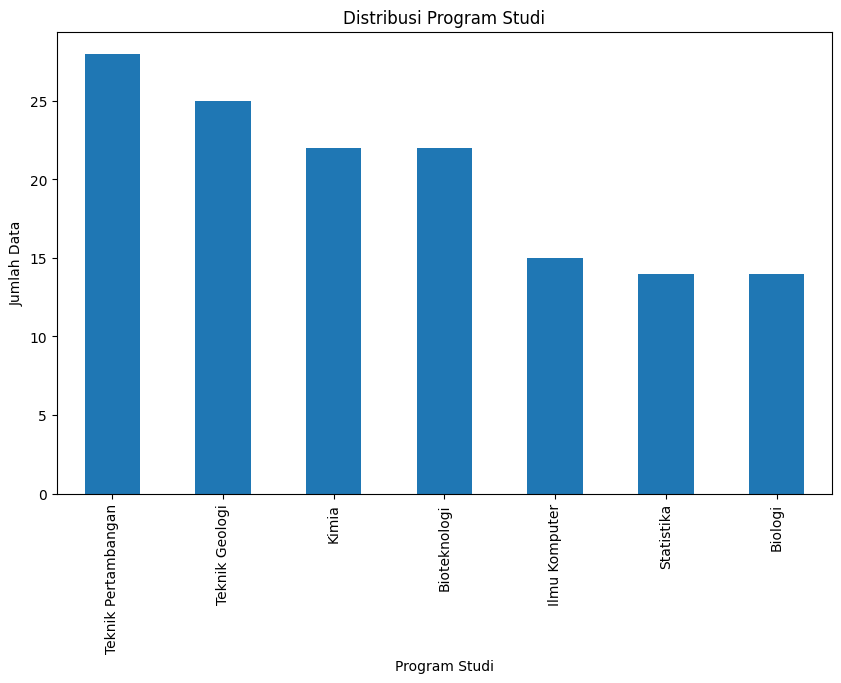

In [17]:
df['Program Studi'].value_counts().plot(
    kind='bar'
)

plt.title(
    'Distribusi Program Studi'
)

plt.xlabel(
    'Program Studi'
)

plt.ylabel(
    'Jumlah Data'
)

plt.show()

### Distribusi Kategori Keluhan

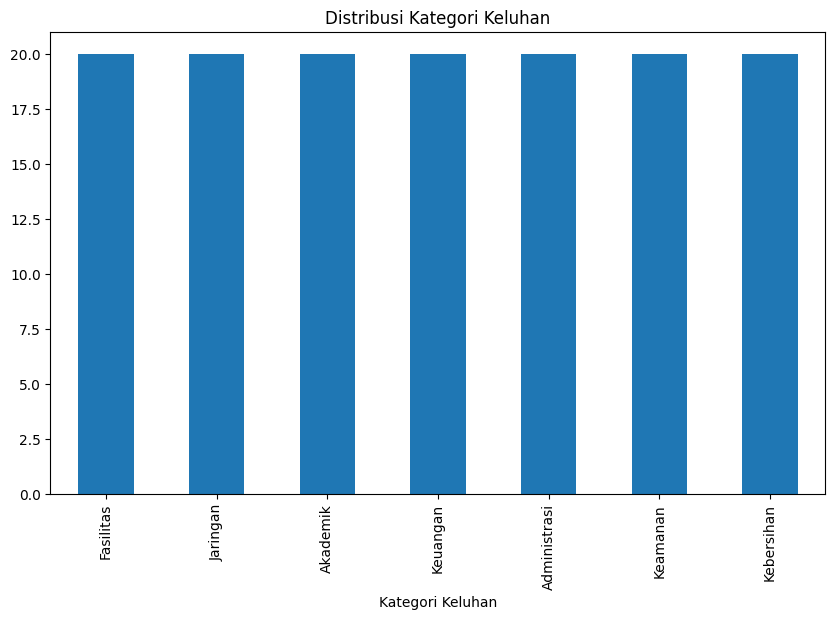

In [18]:
df['Kategori Keluhan'].value_counts().plot(
    kind='bar'
)

plt.title(
    'Distribusi Kategori Keluhan'
)

plt.show()

### Distribusi Lokasi Keluhan

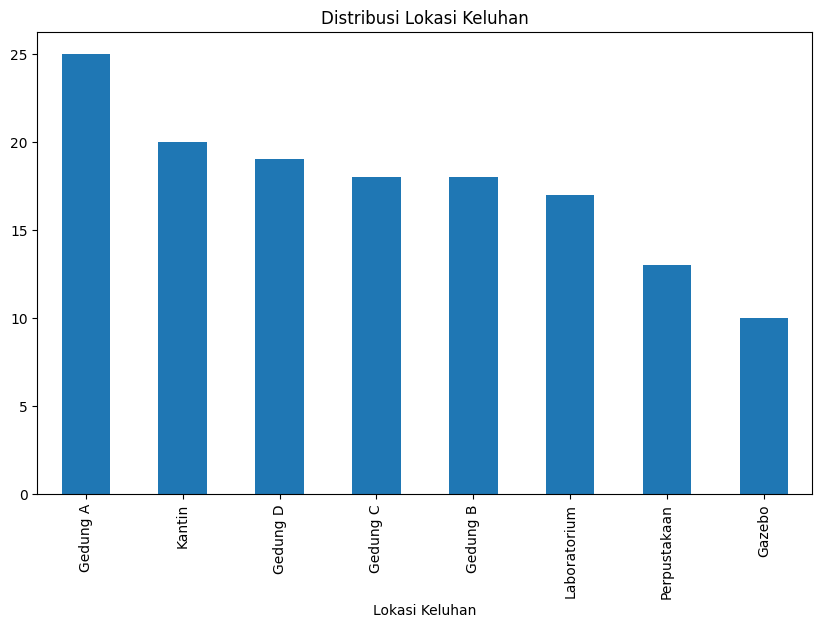

In [19]:
df['Lokasi Keluhan'].value_counts().plot(
    kind='bar'
)

plt.title(
    'Distribusi Lokasi Keluhan'
)

plt.show()

### Distribusi Tingkat Urgensi

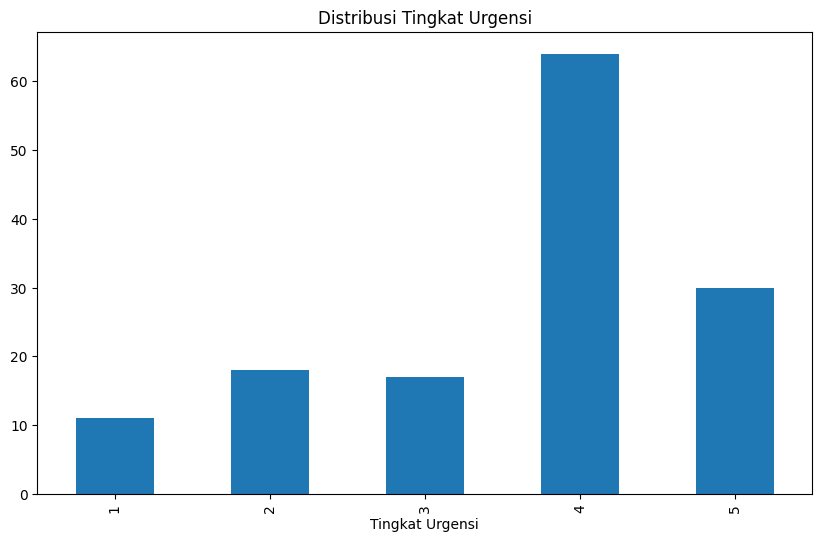

In [20]:
df['Tingkat Urgensi'].value_counts().sort_index().plot(
    kind='bar'
)

plt.title(
    'Distribusi Tingkat Urgensi'
)

plt.show()

### Distribusi Tingkat Gangguan

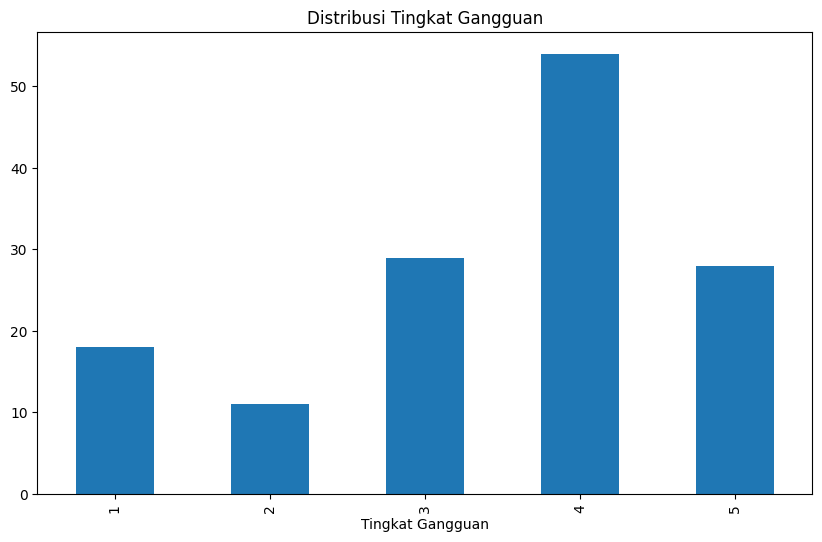

In [21]:
df['Tingkat Gangguan'].value_counts().sort_index().plot(
    kind='bar'
)

plt.title(
    'Distribusi Tingkat Gangguan'
)

plt.show()

### Scatter Plot Tingkat Gangguan vs Tingkat Urgensi

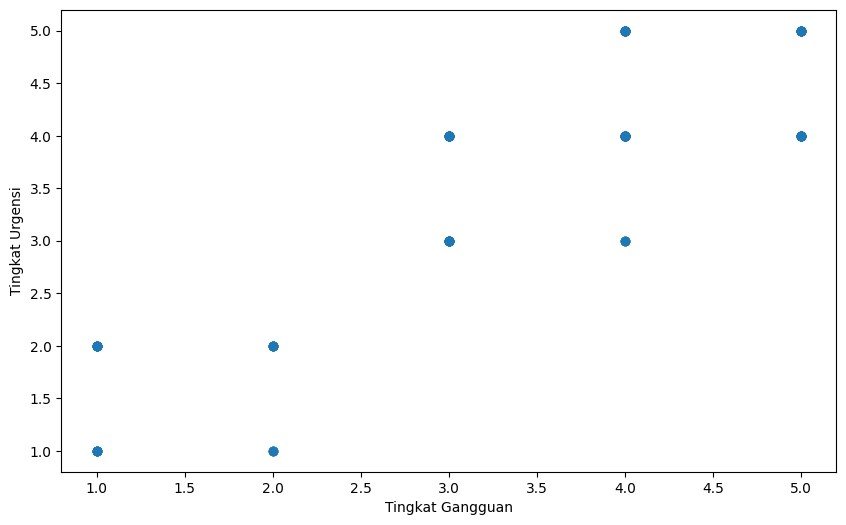

In [23]:
plt.scatter(
    df['Tingkat Gangguan'],
    df['Tingkat Urgensi']
)

plt.xlabel(
    'Tingkat Gangguan'
)

plt.ylabel(
    'Tingkat Urgensi'
)

plt.show()

# 6. Analisis Prioritas Keluhan

Pada tahap ini dilakukan analisis terhadap distribusi prioritas keluhan mahasiswa berdasarkan beberapa atribut pada dataset.

Analisis ini bertujuan untuk mengetahui pola hubungan antara prioritas keluhan dengan:

- Program Studi
- Kategori Keluhan
- Lokasi Keluhan
- Tingkat Urgensi
- Tingkat Gangguan

Hasil analisis ini dapat memberikan gambaran awal mengenai karakteristik keluhan yang sering muncul dan tingkat prioritasnya sebelum dilakukan proses Machine Learning.

## Distribusi Prioritas Berdasarkan Program Studi

Visualisasi ini digunakan untuk mengetahui bagaimana distribusi prioritas keluhan pada setiap program studi.

Melalui grafik ini dapat diketahui program studi mana yang paling banyak menghasilkan keluhan dengan prioritas tinggi, sedang, maupun rendah.

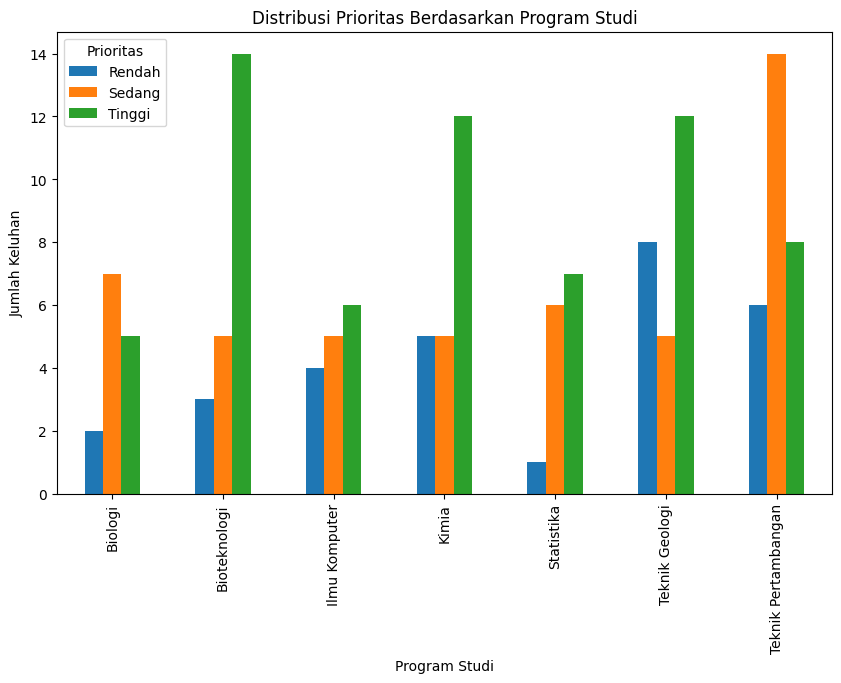

In [58]:
# ==================================================
# PRIORITAS BERDASARKAN PROGRAM STUDI
# ==================================================

pd.crosstab(

    df['Program Studi'],

    df['Prioritas']

).plot(
    kind='bar'
)

plt.title(
    'Distribusi Prioritas Berdasarkan Program Studi'
)

plt.xlabel(
    'Program Studi'
)

plt.ylabel(
    'Jumlah Keluhan'
)

plt.legend(
    title='Prioritas'
)

plt.show()

### Interpretasi

Grafik menunjukkan distribusi jumlah keluhan pada masing-masing program studi berdasarkan kategori prioritas.

Apabila suatu program studi memiliki jumlah keluhan prioritas tinggi yang dominan, maka program studi tersebut memerlukan perhatian lebih dalam peningkatan fasilitas maupun layanan akademik.

## Distribusi Prioritas Berdasarkan Kategori Keluhan

Visualisasi ini bertujuan untuk mengetahui kategori keluhan yang paling sering masuk ke dalam prioritas tinggi, sedang, maupun rendah.

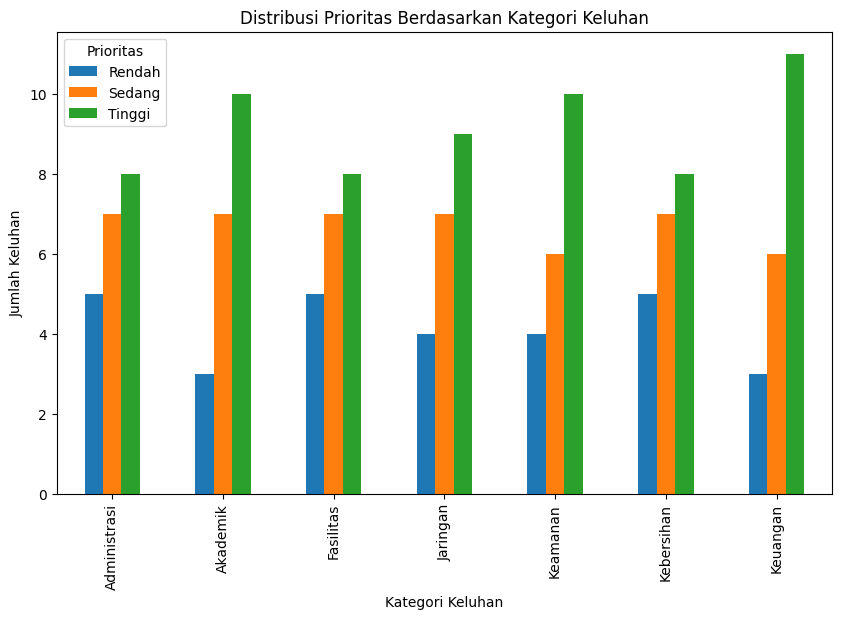

In [59]:
# ==================================================
# PRIORITAS BERDASARKAN KATEGORI KELUHAN
# ==================================================

pd.crosstab(

    df['Kategori Keluhan'],

    df['Prioritas']

).plot(
    kind='bar'
)

plt.title(
    'Distribusi Prioritas Berdasarkan Kategori Keluhan'
)

plt.xlabel(
    'Kategori Keluhan'
)

plt.ylabel(
    'Jumlah Keluhan'
)

plt.legend(
    title='Prioritas'
)

plt.show()

### Interpretasi

Hasil visualisasi dapat digunakan untuk mengidentifikasi kategori keluhan yang paling membutuhkan penanganan segera.

Kategori yang memiliki dominasi prioritas tinggi menunjukkan adanya permasalahan yang lebih mendesak dibandingkan kategori lainnya.

## Visualisasi 12. Rata-rata Tingkat Urgensi pada Setiap Prioritas

Visualisasi ini bertujuan untuk melihat hubungan antara prioritas keluhan dan tingkat urgensi yang diberikan mahasiswa.

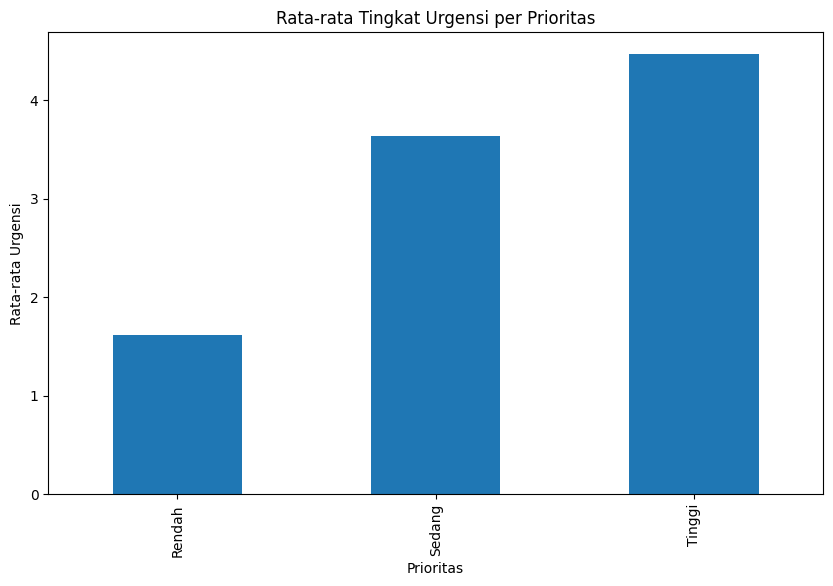

In [60]:
# ==================================================
# RATA-RATA URGENSI PER PRIORITAS
# ==================================================

df.groupby(
    'Prioritas'
)['Tingkat Urgensi'].mean().plot(
    kind='bar'
)

plt.title(
    'Rata-rata Tingkat Urgensi per Prioritas'
)

plt.xlabel(
    'Prioritas'
)

plt.ylabel(
    'Rata-rata Urgensi'
)

plt.show()

# 7. Analisis Teks Keluhan

Tahap ini bertujuan untuk memahami karakteristik teks keluhan mahasiswa sebelum dilakukan proses preprocessing dan klasifikasi.

Analisis teks dilakukan menggunakan:

- WordCloud
- Frekuensi Kata
- Bigram
- Trigram

Analisis ini membantu mengidentifikasi kata-kata yang paling sering muncul pada keluhan mahasiswa.

## WordCloud Seluruh Keluhan

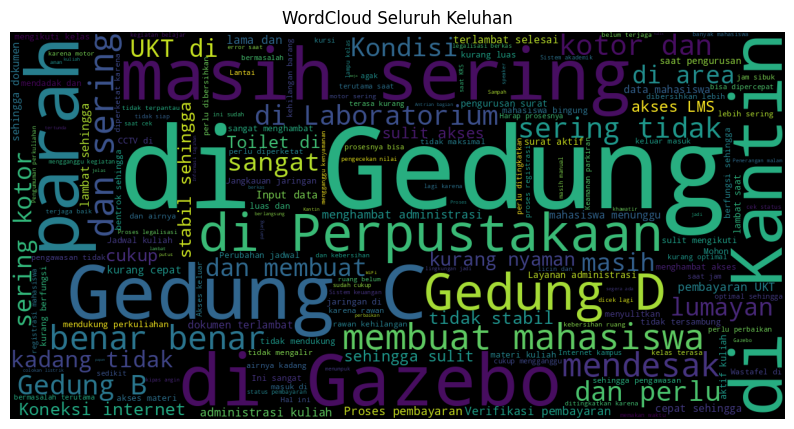

In [61]:
# ==================================================
# WORDCLOUD SEMUA KELUHAN
# ==================================================

text = " ".join(
    df['Keluhan'].astype(str)
)

wordcloud = WordCloud(
    width=1200,
    height=600
).generate(text)

plt.imshow(wordcloud)

plt.axis('off')

plt.title(
    'WordCloud Seluruh Keluhan'
)

plt.show()

### Interpretasi

Semakin besar ukuran kata pada WordCloud, maka semakin sering kata tersebut muncul pada data keluhan mahasiswa.

Kata-kata dominan dapat menjadi indikator permasalahan utama yang sering dikeluhkan mahasiswa.

# 8. Text Preprocessing

Tahap preprocessing dilakukan untuk membersihkan teks sehingga lebih mudah diproses oleh algoritma Machine Learning.

Tahapan preprocessing yang digunakan:

1. Case Folding
2. Cleaning Text
3. Stemming

Output dari tahapan ini adalah teks yang lebih terstruktur dan siap digunakan pada proses ekstraksi fitur.

In [62]:
# ==================================================
# MEMBUAT STEMMER
# ==================================================

factory = StemmerFactory()

stemmer = factory.create_stemmer()

In [63]:
# ==================================================
# FUNGSI PREPROCESSING
# ==================================================

def preprocessing(teks):

    # Mengubah menjadi huruf kecil
    teks = str(teks).lower()

    # Menghapus angka dan simbol
    teks = re.sub(
        r'[^a-zA-Z\s]',
        ' ',
        teks
    )

    # Menghapus spasi berlebih
    teks = re.sub(
        r'\s+',
        ' ',
        teks
    )

    # Stemming Bahasa Indonesia
    teks = stemmer.stem(teks)

    return teks

In [64]:
# ==================================================
# MENERAPKAN PREPROCESSING
# ==================================================

df['clean_text'] = df[
    'Keluhan'
].apply(
    preprocessing
)

df[
    ['Keluhan','clean_text']
].head()

,Keluhan,clean_text
0,Kondisi toilet di Gazebo kadang tidak mendukun...,kondisi toilet di gazebo kadang tidak dukung k...
1,Kondisi speaker di Gedung C kadang tidak mendu...,kondisi speaker di gedung c kadang tidak dukun...
2,kursi di Laboratorium kadang kurang optimal se...,kursi di laboratorium kadang kurang optimal se...
3,kursi di Gazebo agak kurang optimal sehingga k...,kursi di gazebo agak kurang optimal sehingga k...
4,meja di Gedung B kadang kurang optimal sehingg...,meja di gedung b kadang kurang optimal sehingg...


### Interpretasi

Hasil preprocessing menunjukkan bahwa teks telah dibersihkan dari karakter yang tidak diperlukan dan telah diubah ke bentuk kata dasar.

Teks hasil preprocessing akan digunakan pada tahap ekstraksi fitur menggunakan TF-IDF.

# 9. Feature Extraction Menggunakan TF-IDF

TF-IDF digunakan untuk mengubah data teks menjadi data numerik yang dapat dipahami oleh algoritma Machine Learning.

TF-IDF memberikan bobot lebih besar pada kata yang penting dan jarang muncul pada dokumen lain.

In [65]:
# ==================================================
# MENENTUKAN FITUR DAN TARGET
# ==================================================

X = df['clean_text']

y = df['Prioritas']

In [66]:
# Melihat distribusi kelas

y.value_counts()

,count
Prioritas,
Tinggi,64
Sedang,47
Rendah,29


# 10. Pembagian Data Training dan Testing

Dataset dibagi menjadi:

- 80% Data Training
- 20% Data Testing

Data training digunakan untuk melatih model sedangkan data testing digunakan untuk mengukur kemampuan model pada data yang belum pernah dilihat sebelumnya.

In [67]:
# ==================================================
# SPLIT DATA
# ==================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    stratify=y,

    random_state=42

)

print("Jumlah Data Training :", len(X_train))
print("Jumlah Data Testing  :", len(X_test))

Jumlah Data Training : 112
Jumlah Data Testing  : 28


# 11. Perbandingan Algoritma Machine Learning

Penelitian ini membandingkan empat algoritma klasifikasi:

1. Logistic Regression
2. Linear Support Vector Machine (SVM)
3. Multinomial Naive Bayes
4. Random Forest

Perbandingan dilakukan untuk menentukan model terbaik berdasarkan performa evaluasi.

In [68]:
# ==================================================
# DAFTAR MODEL
# ==================================================

models = {

    "Logistic Regression":
    LogisticRegression(max_iter=1000),

    "Linear SVM":
    LinearSVC(),

    "Naive Bayes":
    MultinomialNB(),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )

}

In [69]:
# ==================================================
# TRAINING DAN EVALUASI
# ==================================================

hasil = []

model_tersimpan = {}

for nama, model in models.items():

    pipeline = Pipeline([

        (
            'tfidf',
            TfidfVectorizer(
                max_features=3000,
                ngram_range=(1,2)
            )
        ),

        (
            'classifier',
            model
        )

    ])

    pipeline.fit(
        X_train,
        y_train
    )

    y_pred = pipeline.predict(
        X_test
    )

    acc = accuracy_score(
        y_test,
        y_pred
    )

    prec = precision_score(
        y_test,
        y_pred,
        average='weighted'
    )

    rec = recall_score(
        y_test,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

    hasil.append([
        nama,
        acc,
        prec,
        rec,
        f1
    ])

    model_tersimpan[nama] = pipeline

In [70]:
# ==================================================
# TABEL HASIL
# ==================================================

hasil_df = pd.DataFrame(

    hasil,

    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]

)

hasil_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.607143,0.591766,0.607143,0.572140
1,Linear SVM,0.785714,0.782653,0.785714,0.777555
2,Naive Bayes,0.571429,0.558824,0.571429,0.541667
3,Random Forest,0.678571,0.633929,0.678571,0.646141


# 12. Visualisasi Perbandingan Model

Visualisasi ini digunakan untuk membandingkan performa masing-masing model berdasarkan metrik evaluasi.

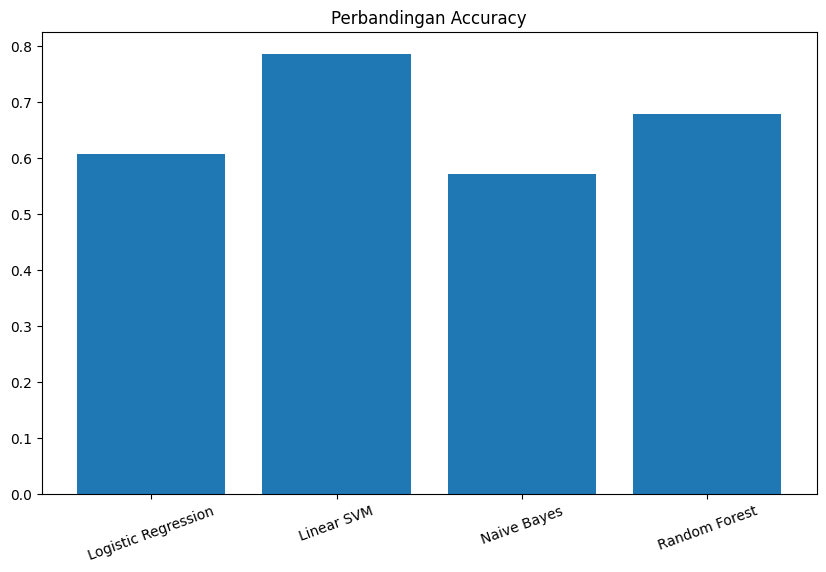

In [71]:
# ==================================================
# ACCURACY
# ==================================================

plt.bar(
    hasil_df['Model'],
    hasil_df['Accuracy']
)

plt.title(
    'Perbandingan Accuracy'
)

plt.xticks(rotation=20)

plt.show()

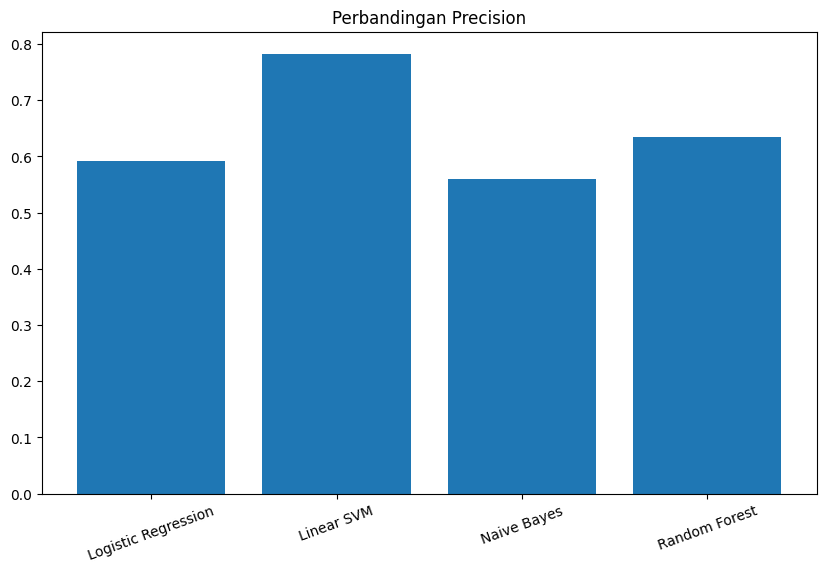

In [72]:
# ==================================================
# PRECISION
# ==================================================

plt.bar(
    hasil_df['Model'],
    hasil_df['Precision']
)

plt.title(
    'Perbandingan Precision'
)

plt.xticks(rotation=20)

plt.show()

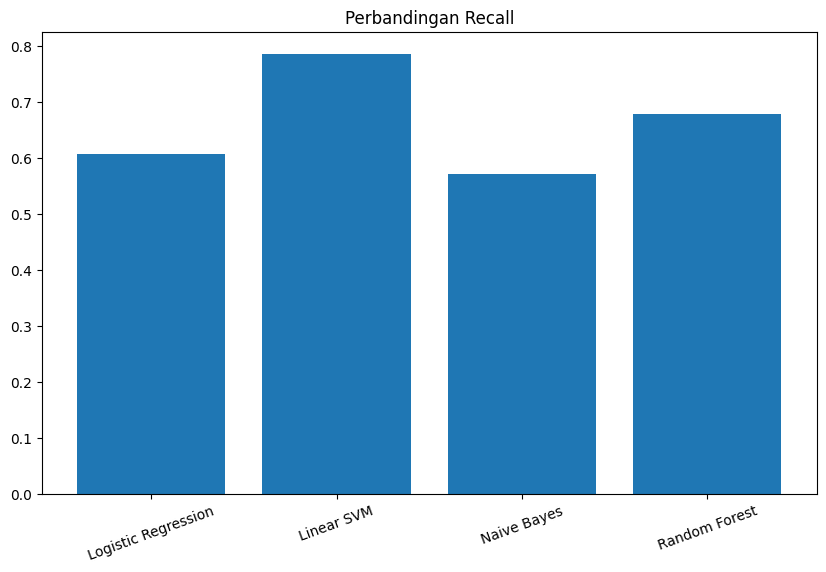

In [73]:
# ==================================================
# RECALL
# ==================================================

plt.bar(
    hasil_df['Model'],
    hasil_df['Recall']
)

plt.title(
    'Perbandingan Recall'
)

plt.xticks(rotation=20)

plt.show()

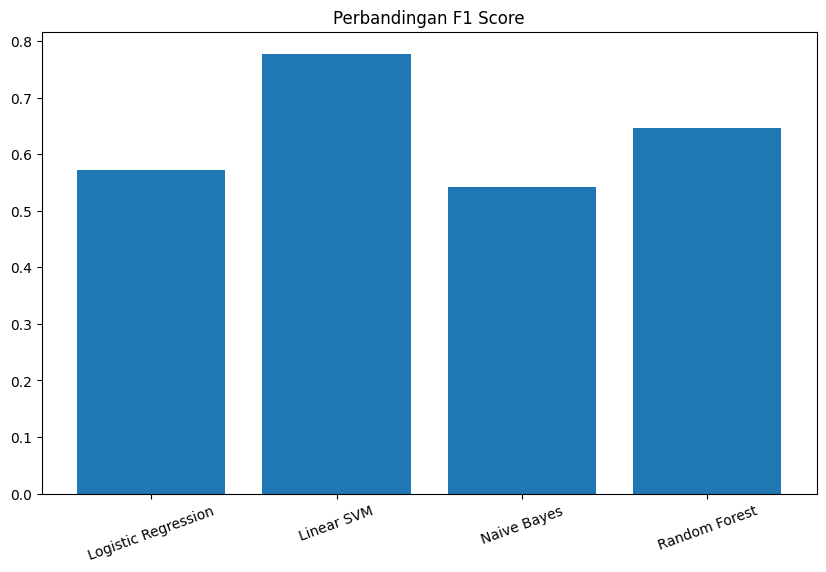

In [74]:
# ==================================================
# F1 SCORE
# ==================================================

plt.bar(
    hasil_df['Model'],
    hasil_df['F1 Score']
)

plt.title(
    'Perbandingan F1 Score'
)

plt.xticks(rotation=20)

plt.show()

# 13. Pemilihan Model Terbaik

Model terbaik dipilih berdasarkan nilai F1 Score tertinggi karena klasifikasi memiliki lebih dari dua kelas.

In [75]:
hasil_df = hasil_df.sort_values(
    by='F1 Score',
    ascending=False
)

hasil_df

,Model,Accuracy,Precision,Recall,F1 Score
1,Linear SVM,0.785714,0.782653,0.785714,0.777555
3,Random Forest,0.678571,0.633929,0.678571,0.646141
0,Logistic Regression,0.607143,0.591766,0.607143,0.572140
2,Naive Bayes,0.571429,0.558824,0.571429,0.541667


In [76]:
best_model_name = hasil_df.iloc[0]['Model']

print(
    "Model Terbaik :",
    best_model_name
)

Model Terbaik : Linear SVM


In [77]:
best_model = model_tersimpan[
    best_model_name
]

# 14. Confusion Matrix

Confusion Matrix digunakan untuk melihat detail hasil prediksi pada setiap kelas prioritas.

In [78]:
# ==================================================
# PREDIKSI MODEL TERBAIK
# ==================================================

y_pred = best_model.predict(
    X_test
)

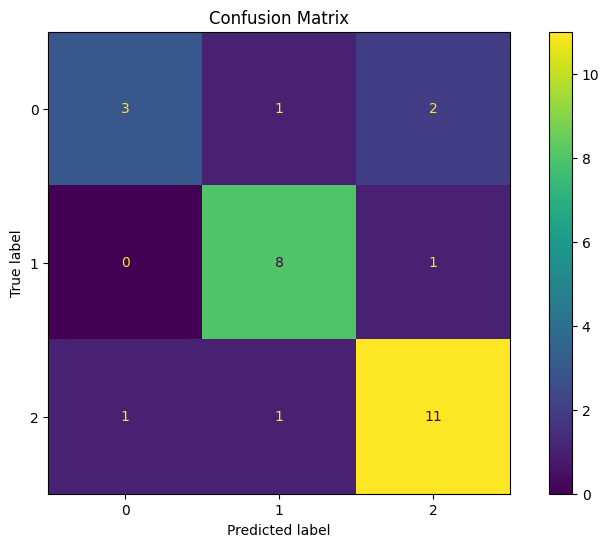

In [79]:
# ==================================================
# CONFUSION MATRIX
# ==================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title(
    'Confusion Matrix'
)

plt.show()

# 15. Classification Report

Classification Report menampilkan nilai Precision, Recall, dan F1 Score untuk setiap kelas prioritas.

In [80]:
print(

    classification_report(
        y_test,
        y_pred
    )

)

              precision    recall  f1-score   support

      Rendah       0.75      0.50      0.60         6
      Sedang       0.80      0.89      0.84         9
      Tinggi       0.79      0.85      0.81        13

    accuracy                           0.79        28
   macro avg       0.78      0.75      0.75        28
weighted avg       0.78      0.79      0.78        28



# 16. Cross Validation

Cross Validation digunakan untuk mengukur kestabilan model pada berbagai pembagian data.

In [81]:
cv_scores = cross_val_score(

    best_model,

    X,

    y,

    cv=5,

    scoring='accuracy'

)

print(cv_scores)

print(
    "Rata-rata Accuracy:",
    cv_scores.mean()
)

[0.96428571 0.89285714 0.96428571 0.71428571 0.71428571]
Rata-rata Accuracy: 0.85


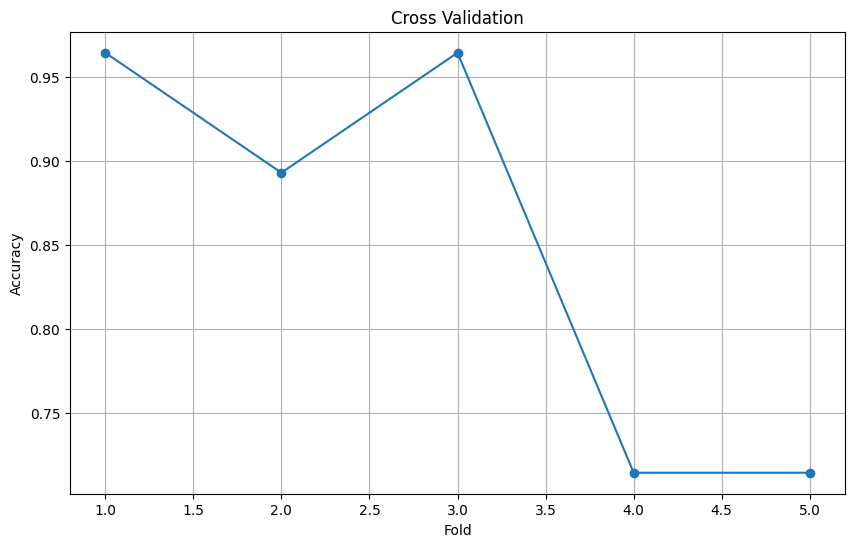

In [82]:
plt.plot(
    range(1,6),
    cv_scores,
    marker='o'
)

plt.title(
    'Cross Validation'
)

plt.xlabel('Fold')

plt.ylabel('Accuracy')

plt.grid()

plt.show()

# 17. Analisis Overfitting

Overfitting dianalisis dengan membandingkan performa data training dan testing.

In [83]:
train_acc = best_model.score(
    X_train,
    y_train
)

test_acc = best_model.score(
    X_test,
    y_test
)

print(
    "Training Accuracy:",
    train_acc
)

print(
    "Testing Accuracy:",
    test_acc
)

Training Accuracy: 1.0
Testing Accuracy: 0.7857142857142857


In [84]:
selisih = abs(
    train_acc - test_acc
)

print(
    "Selisih:",
    selisih
)

Selisih: 0.2142857142857143


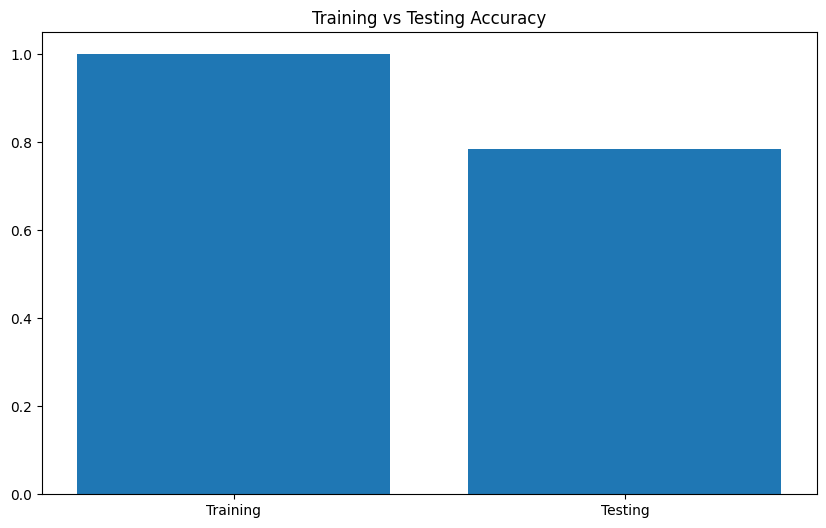

In [85]:
plt.bar(

    ['Training','Testing'],

    [train_acc,test_acc]

)

plt.title(
    'Training vs Testing Accuracy'
)

plt.show()

### Interpretasi

Jika selisih training dan testing accuracy terlalu besar, maka model mengalami overfitting.

Sebaliknya, jika selisih kecil maka model memiliki kemampuan generalisasi yang baik.

# 18. Learning Curve

Learning Curve digunakan untuk menganalisis proses pembelajaran model serta mendeteksi potensi overfitting atau underfitting.

In [86]:
train_sizes, train_scores, test_scores = learning_curve(

    best_model,

    X,

    y,

    cv=5,

    scoring='accuracy'
)

In [ ]:
train_mean = train_scores.mean(
    axis=1
)

test_mean = test_scores.mean(
    axis=1
)

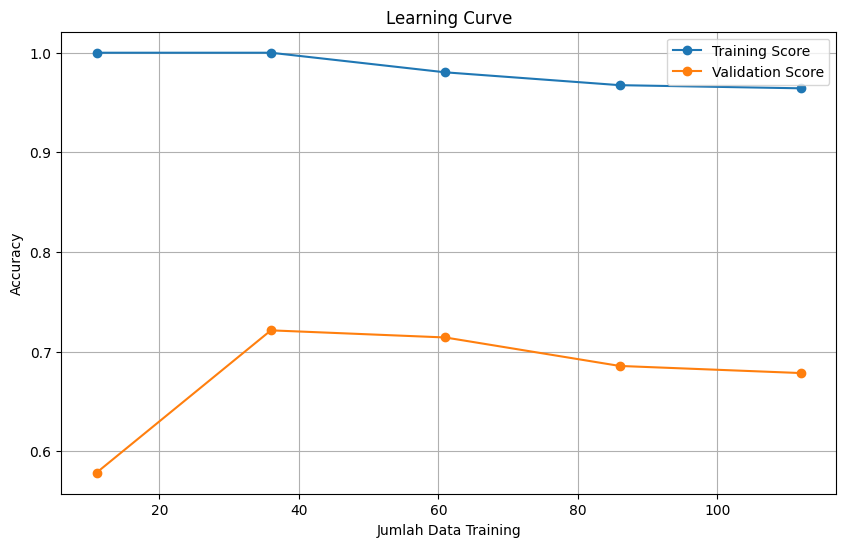

In [87]:
plt.plot(

    train_sizes,

    train_mean,

    marker='o',

    label='Training Score'

)

plt.plot(

    train_sizes,

    test_mean,

    marker='o',

    label='Validation Score'

)

plt.title(
    'Learning Curve'
)

plt.xlabel(
    'Jumlah Data Training'
)

plt.ylabel(
    'Accuracy'
)

plt.legend()

plt.grid()

plt.show()

# 19. Pengujian Model dengan Data Baru

Tahap ini bertujuan untuk memastikan model dapat digunakan untuk memprediksi prioritas keluhan baru.

In [95]:
contoh_keluhan = [

    "wifi kampus sangat lambat",

    "laboratorium komputer rusak",

    "pelayanan administrasi cukup baik",

    "proyektor ruang kuliah tidak berfungsi",

    "Kondisi toilet di Gazebo kadang tidak mendukung perkuliahan"

]

In [96]:
prediksi = best_model.predict(
    contoh_keluhan
)

for teks, hasil in zip(
    contoh_keluhan,
    prediksi
):

    print("Keluhan :", teks)

    print("Prioritas :", hasil)

    print("-"*50)

Keluhan : wifi kampus sangat lambat
Prioritas : Tinggi
--------------------------------------------------
Keluhan : laboratorium komputer rusak
Prioritas : Tinggi
--------------------------------------------------
Keluhan : pelayanan administrasi cukup baik
Prioritas : Sedang
--------------------------------------------------
Keluhan : proyektor ruang kuliah tidak berfungsi
Prioritas : Tinggi
--------------------------------------------------
Keluhan : Kondisi toilet di Gazebo kadang tidak mendukung perkuliahan
Prioritas : Rendah
--------------------------------------------------


# 20. Menyimpan Model Terbaik

Tahap ini dilakukan untuk menyimpan model terbaik yang telah dilatih sehingga dapat digunakan kembali tanpa perlu melakukan proses training ulang.

Model akan disimpan dalam format:

- .pkl (Pickle)

File model yang telah disimpan dapat digunakan untuk deployment maupun prediksi pada data baru.

In [97]:
# ==================================================
# IMPORT LIBRARY
# ==================================================

import pickle

In [98]:
# ==================================================
# MENYIMPAN MODEL TERBAIK
# ==================================================

with open(
    'model_prioritas_keluhan.pkl',
    'wb'
) as file:

    pickle.dump(
        best_model,
        file
    )

print(
    "Model berhasil disimpan"
)

Model berhasil disimpan


In [99]:
import os

os.listdir()

['.config',
 '.ipynb_checkpoints',
 'data_klmpk10_sintetis.xlsx',
 'model_prioritas_keluhan.pkl',
 'sample_data']